In [ ]:
#!unzip -q /content/sample_data/dataset.zip -d /content/sample_data
#!unzip -q /content/sample_data/sample_data.zip -d /content/sample_data

# Fase 1 — Reconocimiento de Patrones: Firmas Off-Line
## Universidad Autónoma de Aguascalientes
## Ingeniería en Computación Inteligente — Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864) — Semestre Enero–Junio 2026

---

**Descripción general**

Este notebook combina dos datasets para lograr un sistema completo y generalizable:

| Fase | Dataset | Propósito |
|------|---------|----------|
| A — Entrenar U-Net | TrainSet/TestSet (cheques + máscaras) | Aprender a localizar firmas en cualquier cheque |
| B — Extraer firmas | Dataset personal (real/ + fake/) | Obtener la firma binarizada de cada imagen |
| C — Clasificadores | Firmas extraídas + sintéticos | Aprender a distinguir auténtica vs falsificada |
| D — Demo | real_test.jpg + fake_test.jpg | Verificación de extremo a extremo |

```
dataset_cheques/          dataset_personal/
├── TrainSet/X + y        ├── real/   (15 firmas auténticas)
└── TestSet/X  + y        ├── fake/   (15 firmas falsificadas)
       ↓                  ├── real_test.jpg
   U-Net                  └── fake_test.jpg
   entrenada                     ↓
       └──────────────── extracción ──────────── clasificadores
```
---

## 0 · Dependencias

In [ ]:
# !pip install torch torchvision opencv-python-headless numpy matplotlib
# !pip install scikit-learn scikit-image scipy pandas tqdm joblib -q

import os, glob, warnings, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from tqdm.notebook import tqdm
from scipy.ndimage import rotate as ndrotate

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from skimage import filters

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')
np.random.seed(42); random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✔  Dependencias cargadas.  Dispositivo: {DEVICE}')

✔  Dependencias cargadas.  Dispositivo: cuda


---
## Etapa 1 · Selección de Datos
### 1A — Dataset de cheques (para U-Net)
### 1B — Dataset personal (para clasificadores)

In [ ]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
# Dataset de cheques (para entrenar U-Net)
CHEQUE_ROOT = './content/sample_data/'   # ← ajusta
TRAIN_X = os.path.join(CHEQUE_ROOT, 'TrainSet', 'X')
TRAIN_Y = os.path.join(CHEQUE_ROOT, 'TrainSet', 'y')
TEST_X  = os.path.join(CHEQUE_ROOT, 'TestSet',  'X')
TEST_Y  = os.path.join(CHEQUE_ROOT, 'TestSet',  'y')

# Dataset personal (para clasificadores)
PERSONAL_ROOT = './content/sample_data/dataset'         # ← ajusta
REAL_DIR  = os.path.join(PERSONAL_ROOT, 'real')
FAKE_DIR  = os.path.join(PERSONAL_ROOT, 'fake')
TEST_REAL = os.path.join(PERSONAL_ROOT, 'real_test.jpg')
TEST_FAKE = os.path.join(PERSONAL_ROOT, 'fake_test.jpg')

IMG_EXTS = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff')

def load_paths(folder):
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(paths)

def sorted_numbered(folder):
    """Carga y ordena numéricamente archivos con patrón X_n / y_n."""
    import re
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(folder, ext)))
    paths.sort(key=lambda p: int(re.search(r'(\d+)', os.path.basename(p)).group()))
    return paths

# Dataset de cheques
train_x = sorted_numbered(TRAIN_X)
train_y = sorted_numbered(TRAIN_Y)
test_x  = sorted_numbered(TEST_X)
test_y  = sorted_numbered(TEST_Y)

# Dataset personal
real_paths = load_paths(REAL_DIR)
fake_paths = load_paths(FAKE_DIR)

print(f'Dataset cheques — Train: {len(train_x)} | Test: {len(test_x)}')
print(f'Dataset personal — Real: {len(real_paths)} | Fake: {len(fake_paths)}')
print(f'Test real: {os.path.exists(TEST_REAL)} | Test fake: {os.path.exists(TEST_FAKE)}')

assert len(train_x) == len(train_y), 'Pares TrainSet no coinciden'
assert len(test_x)  == len(test_y),  'Pares TestSet no coinciden'

Dataset cheques — Train: 129 | Test: 29
Dataset personal — Real: 15 | Fake: 15
Test real: True | Test fake: True


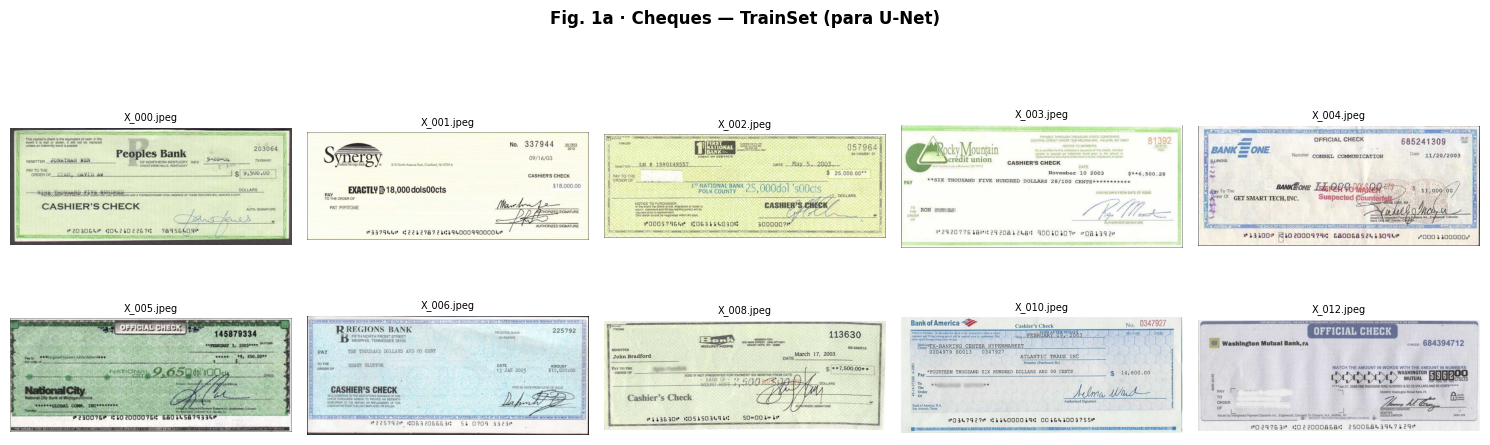

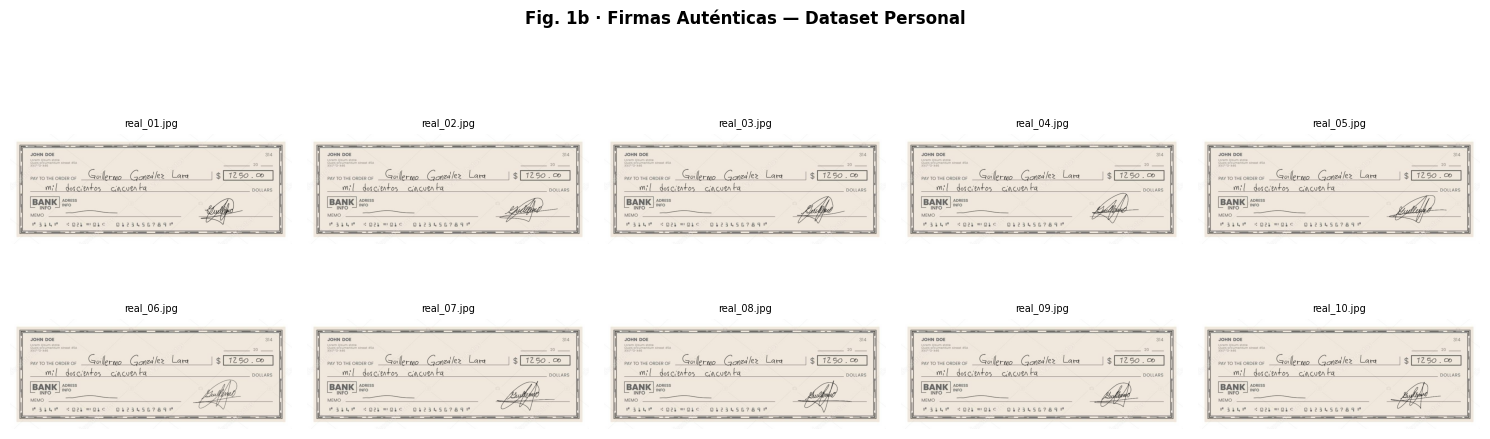

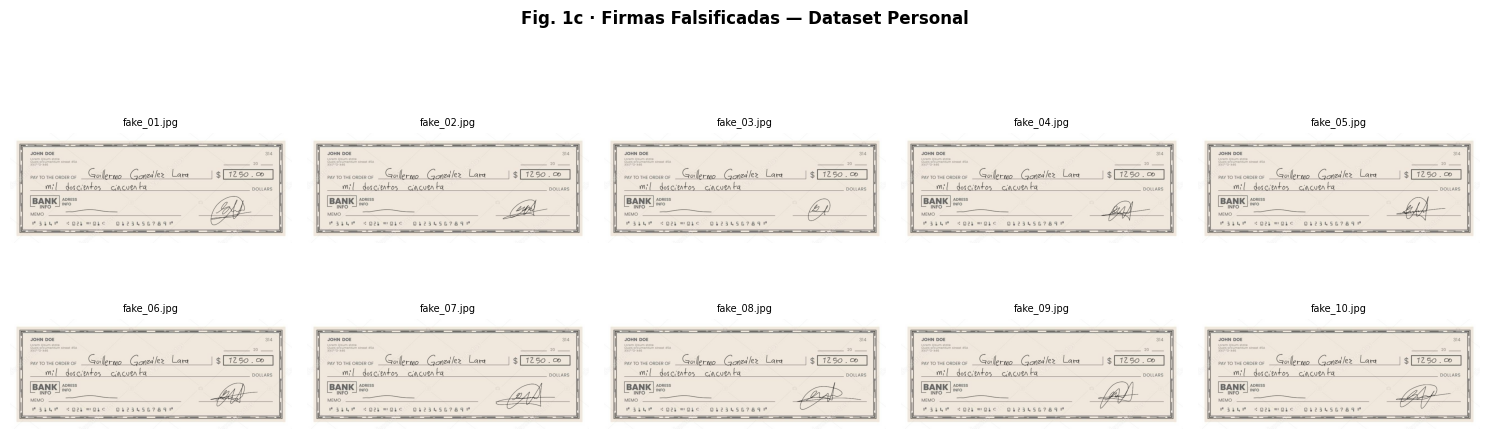

In [ ]:
# ── Fig. 1 · Mosaico de ambos datasets ───────────────────────────────────────
def plot_mosaic(paths, title, cols=5, max_imgs=10, bgr=True):
    paths = paths[:max_imgs]
    rows  = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = np.array(axes).flatten()
    for ax, p in zip(axes, paths):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if bgr else img
        ax.imshow(img); ax.set_title(os.path.basename(p), fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]: ax.axis('off')
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

plot_mosaic(train_x,   'Fig. 1a · Cheques — TrainSet (para U-Net)')
plot_mosaic(real_paths,'Fig. 1b · Firmas Auténticas — Dataset Personal')
plot_mosaic(fake_paths,'Fig. 1c · Firmas Falsificadas — Dataset Personal')

---
## Etapa 2 · Pre-procesamiento
### 2A — Entrenamiento de U-Net (dataset de cheques)

La U-Net aprende a segmentar la firma en el cheque usando los pares `(X_n, y_n)`. Una vez entrenada, puede extraer la firma de **cualquier cheque nuevo**, incluyendo los del dataset personal si fueran cheques completos.

In [ ]:
# ── Parámetros U-Net ─────────────────────────────────────────────────────────
IMG_SIZE    = 256
FIRMA_X_PCT = 0.50   # pre-recorte: inicio horizontal
FIRMA_Y_PCT = 0.55   # pre-recorte: inicio vertical
FIRMA_Y_FIN = 0.88   # pre-recorte: fin vertical (excluye MICR)
THRESHOLD   = 0.3    # umbral bajo para capturar trazos finos
TARGET_W, TARGET_H = 200, 80   # tamaño final de la firma extraída


# ── Dataset PyTorch ───────────────────────────────────────────────────────────
class ChequeDataset(Dataset):
    """
    Recorta la región inferior derecha del cheque Y de la máscara
    con los mismos porcentajes que en inferencia — esto es crítico.
    Entrada a la red: RGB (3 canales) 256×256.
    """
    def __init__(self, x_paths, y_paths, augment=False):
        self.x_paths = x_paths
        self.y_paths = y_paths
        self.augment = augment

    def __len__(self): return len(self.x_paths)

    def __getitem__(self, idx):
        img_full  = cv2.imread(self.x_paths[idx])
        mask_full = cv2.imread(self.y_paths[idx], cv2.IMREAD_GRAYSCALE)
        h, w = img_full.shape[:2]
        x1 = int(w * FIRMA_X_PCT)
        y1 = int(h * FIRMA_Y_PCT)
        y2 = int(h * FIRMA_Y_FIN)

        img  = cv2.cvtColor(img_full[y1:y2, x1:], cv2.COLOR_BGR2RGB)
        mask = mask_full[y1:y2, x1:]
        if img.size == 0 or mask.size == 0:
            img  = cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB)
            mask = mask_full

        img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                          interpolation=cv2.INTER_NEAREST)
        mask   = (mask > 127).astype(np.float32)
        img_t  = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        mask_t = torch.from_numpy(mask).unsqueeze(0)

        if self.augment:
            if torch.rand(1) > 0.5: img_t, mask_t = TF.hflip(img_t), TF.hflip(mask_t)
            if torch.rand(1) > 0.5: img_t, mask_t = TF.vflip(img_t), TF.vflip(mask_t)
            angle  = float(torch.FloatTensor(1).uniform_(-20, 20))
            img_t  = TF.rotate(img_t,  angle)
            mask_t = TF.rotate(mask_t, angle)
            if torch.rand(1) > 0.5:
                img_t = TF.adjust_brightness(
                    img_t, float(torch.FloatTensor(1).uniform_(0.7, 1.3)))
            if torch.rand(1) > 0.5:
                img_t = TF.adjust_contrast(
                    img_t, float(torch.FloatTensor(1).uniform_(0.7, 1.3)))
        return img_t, mask_t


train_ds = ChequeDataset(train_x, train_y, augment=True)
test_ds  = ChequeDataset(test_x,  test_y,  augment=False)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

xb, yb = next(iter(train_dl))
print(f'Batch cheque: {xb.shape}  |  Batch máscara: {yb.shape}')

Batch cheque: torch.Size([8, 3, 256, 256])  |  Batch máscara: torch.Size([8, 1, 256, 256])


In [ ]:
# ── Arquitectura U-Net con Attention Gates (RGB, filtros grandes) ────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=False),
                                   nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=False),
                                   nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False),
                                   nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))


class UNet(nn.Module):
    """U-Net + Attention Gates. Entrada RGB (3ch). Filtros [64,128,256,512]."""
    def __init__(self, in_ch=3, f=[64, 128, 256, 512]):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_ch, f[0])
        self.e2 = DoubleConv(f[0],  f[1])
        self.e3 = DoubleConv(f[1],  f[2])
        self.e4 = DoubleConv(f[2],  f[3])
        self.bn = DoubleConv(f[3],  f[3]*2)
        self.att4 = AttentionGate(f[3],   f[3],   f[3]//2)
        self.att3 = AttentionGate(f[2],   f[2],   f[2]//2)
        self.att2 = AttentionGate(f[1],   f[1],   f[1]//2)
        self.att1 = AttentionGate(f[0],   f[0],   f[0]//2)
        self.u4 = nn.ConvTranspose2d(f[3]*2, f[3], 2, stride=2)
        self.d4 = DoubleConv(f[3]*2, f[3])
        self.u3 = nn.ConvTranspose2d(f[3],   f[2], 2, stride=2)
        self.d3 = DoubleConv(f[2]*2, f[2])
        self.u2 = nn.ConvTranspose2d(f[2],   f[1], 2, stride=2)
        self.d2 = DoubleConv(f[1]*2, f[1])
        self.u1 = nn.ConvTranspose2d(f[1],   f[0], 2, stride=2)
        self.d1 = DoubleConv(f[0]*2, f[0])
        self.out = nn.Conv2d(f[0], 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b  = self.bn(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b),  self.att4(self.u4(b),  e4)], 1))
        d3 = self.d3(torch.cat([self.u3(d4), self.att3(self.u3(d4), e3)], 1))
        d2 = self.d2(torch.cat([self.u2(d3), self.att2(self.u2(d3), e2)], 1))
        d1 = self.d1(torch.cat([self.u1(d2), self.att1(self.u1(d2), e1)], 1))
        return torch.sigmoid(self.out(d1))


model = UNet().to(DEVICE)
print(f'Attention U-Net — {sum(p.numel() for p in model.parameters()):,} parámetros')

Attention U-Net — 31,388,201 parámetros


In [ ]:
# ── Función de pérdida: Focal Loss + Dice ─────────────────────────────────────
def dice_loss(pred, target, smooth=1e-6):
    p, t = pred.view(-1), target.view(-1)
    return 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def focal_loss(pred, target, alpha=0.8, gamma=2.0):
    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt  = torch.exp(-bce)
    return (alpha * (1-pt)**gamma * bce).mean()

def loss_fn(pred, target):
    return focal_loss(pred, target) + dice_loss(pred, target)

def dice_score(pred_bin, target):
    p = pred_bin.view(-1).float()
    t = target.view(-1).float()
    return (2*(p*t).sum() + 1.) / (p.sum() + t.sum() + 1.)

print('Funciones de pérdida definidas ✔')

Funciones de pérdida definidas ✔


In [ ]:
# ── Entrenamiento con Early Stopping ─────────────────────────────────────────
EPOCHS     = 150
LR         = 3e-4
PATIENCE   = 20
MODEL_PATH = 'unet_firmas_best.pth'

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5, min_lr=1e-6)

hist_train, hist_val = [], []
best_val, epochs_sin_mejora = float('inf'), 0

for epoch in range(1,1):
    model.train(); tl = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); optimizer.step()
        tl += loss.item()
    tl /= len(train_dl)

    model.eval(); vl = 0.0
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += loss_fn(model(xb), yb).item()
    vl /= len(test_dl)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(vl)
    if optimizer.param_groups[0]['lr'] < old_lr:
        print(f'  ↓ LR: {old_lr:.2e} → {optimizer.param_groups[0]["lr"]:.2e}')

    hist_train.append(tl); hist_val.append(vl)

    if vl < best_val:
        best_val = vl; epochs_sin_mejora = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        epochs_sin_mejora += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:3d}/{EPOCHS}  Train={tl:.4f}  Val={vl:.4f}  '
              f'Sin mejora={epochs_sin_mejora}/{PATIENCE}')

    if epochs_sin_mejora >= PATIENCE:
        print(f'Early stopping en época {epoch}')
        break

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'\n✔  Entrenamiento finalizado — mejor Val Loss: {best_val:.4f}')

Época   1/150  Train=1.1354  Val=1.0572  Sin mejora=0/20
Época  10/150  Train=0.9454  Val=0.8602  Sin mejora=0/20
Época  20/150  Train=0.8288  Val=0.7222  Sin mejora=0/20
Época  30/150  Train=0.5466  Val=0.5986  Sin mejora=2/20
Época  40/150  Train=0.4307  Val=0.5400  Sin mejora=4/20
Época  50/150  Train=0.3968  Val=0.4848  Sin mejora=8/20
  ↓ LR: 3.00e-04 → 1.50e-04
Época  60/150  Train=0.3514  Val=0.4499  Sin mejora=6/20
  ↓ LR: 1.50e-04 → 7.50e-05
Época  70/150  Train=0.3561  Val=0.4253  Sin mejora=16/20
  ↓ LR: 7.50e-05 → 3.75e-05
Early stopping en época 74

✔  Entrenamiento finalizado — mejor Val Loss: 0.3848


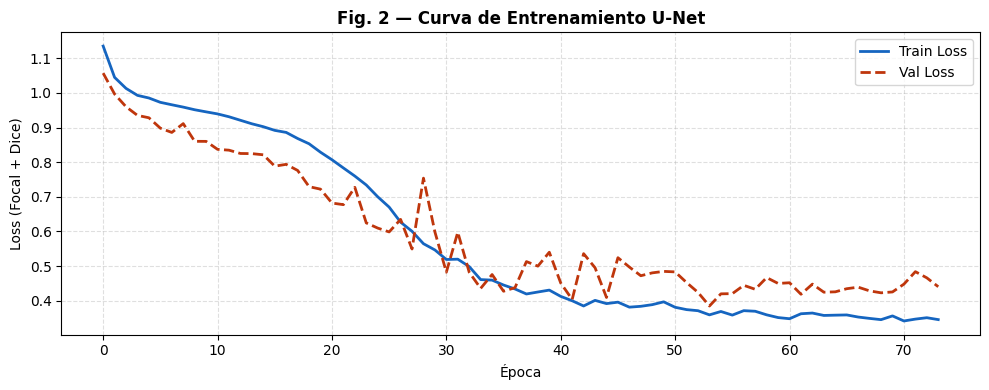

In [ ]:
# ── Fig. 2 · Curvas de entrenamiento ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_train, label='Train Loss', color='#1565C0', lw=2)
ax.plot(hist_val,   label='Val Loss',   color='#BF360C', lw=2, linestyle='--')
ax.set_xlabel('Época'); ax.set_ylabel('Loss (Focal + Dice)')
ax.set_title('Fig. 2 — Curva de Entrenamiento U-Net',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

In [ ]:
# ── Función de extracción con U-Net ──────────────────────────────────────────
def extraer_firma_unet(img_bgr, umbral=THRESHOLD):
    """
    Extrae la firma de un cheque completo (BGR) en tres pasos:
    1. Pre-recorte de la región inferior derecha (mismos % que en train).
    2. U-Net sobre el recorte → máscara de probabilidad.
    3. Post-procesamiento morfológico + bounding box.
    Devuelve (firma_bin uint8 [0,255], mascara_full uint8).
    """
    h, w = img_bgr.shape[:2]
    x1 = int(w * FIRMA_X_PCT); y1 = int(h * FIRMA_Y_PCT)
    y2 = int(h * FIRMA_Y_FIN)
    region = img_bgr[y1:y2, x1:]
    if region.size == 0: region = img_bgr

    img_rgb = cv2.cvtColor(region, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    tensor  = torch.from_numpy(
        img_res.transpose(2, 0, 1)).float() / 255.0
    with torch.no_grad():
        pred = model(tensor.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()

    rh, rw  = region.shape[:2]
    mascara = (pred > umbral).astype(np.uint8) * 255
    mascara = cv2.resize(mascara, (rw, rh), interpolation=cv2.INTER_NEAREST)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE,
                  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,
                  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)))

    gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    if np.sum(mascara > 0) > 300:
        firma  = cv2.bitwise_and(gray, gray, mask=mascara)
        coords = cv2.findNonZero(mascara)
        if coords is not None:
            rx, ry, fw, fh = cv2.boundingRect(coords)
            mx, my = int(fw*0.05), int(fh*0.05)
            rx=max(0,rx-mx); ry=max(0,ry-my)
            fw=min(rw-rx,fw+2*mx); fh=min(rh-ry,fh+2*my)
            firma = firma[ry:ry+fh, rx:rx+fw]
    else:
        print('  ⚠️  U-Net sin detección — usando recorte directo')
        firma = gray; mascara[:] = 255

    if firma.size == 0: firma = gray

    # Binarizar: trazos = blanco
    _, firma_bin  = cv2.threshold(firma, 0, 255, cv2.THRESH_BINARY_INV)
    firma_norm    = cv2.resize(firma_bin, (TARGET_W, TARGET_H),
                               interpolation=cv2.INTER_AREA)
    _, firma_final = cv2.threshold(firma_norm, 127, 255, cv2.THRESH_BINARY)

    mascara_full = np.zeros((h, w), dtype=np.uint8)
    mascara_full[y1:y2, x1:] = mascara
    return firma_final, mascara_full


print('extraer_firma_unet() definida ✔')

extraer_firma_unet() definida ✔


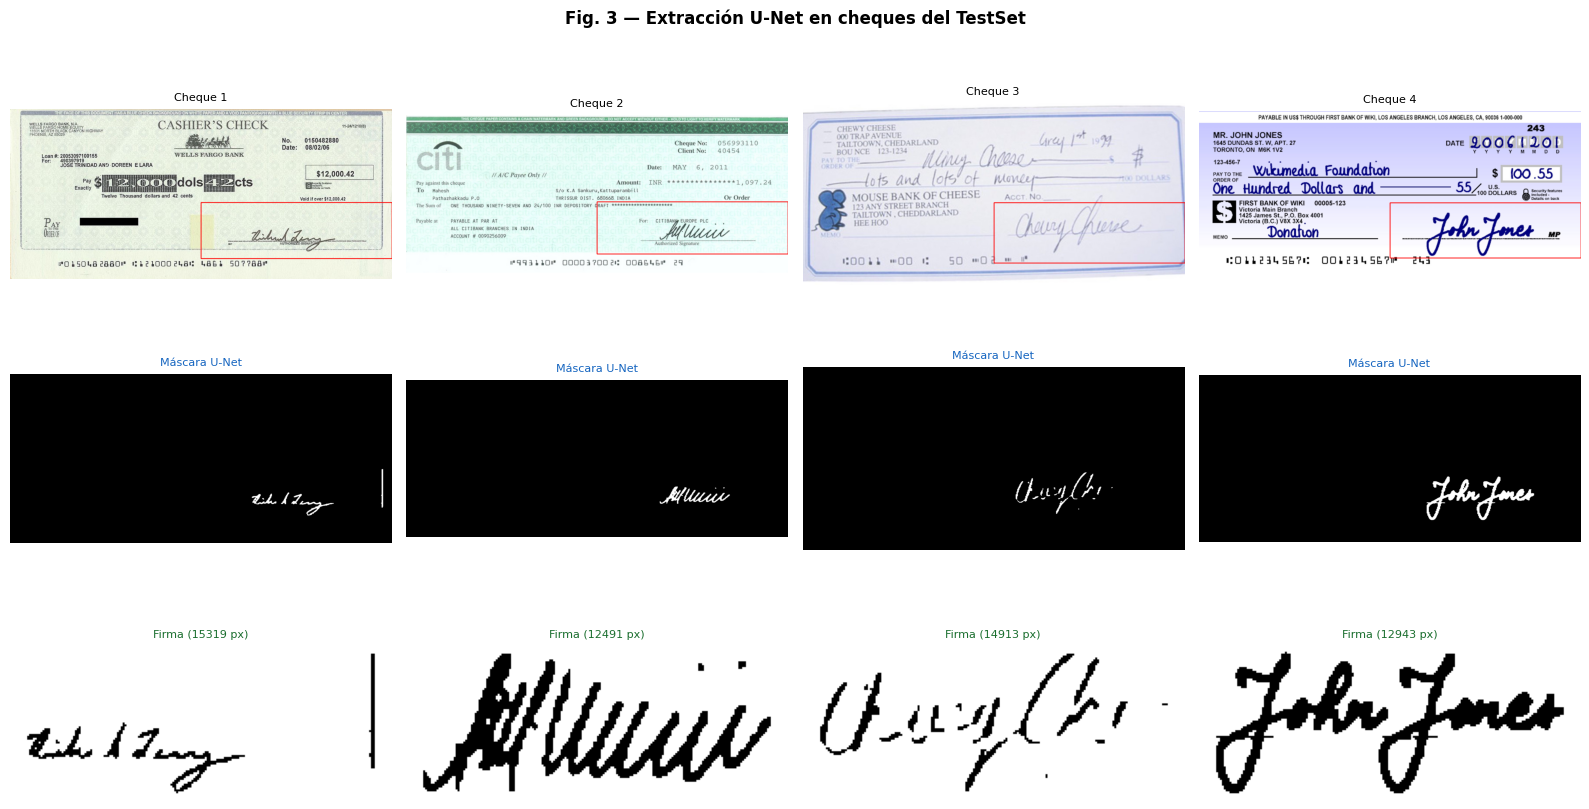

In [ ]:
# ── Fig. 3 · Pipeline U-Net en cheques del TestSet ────────────────────────────
n_vis = min(4, len(test_x))
fig, axes = plt.subplots(3, n_vis, figsize=(n_vis*4, 9))
fig.suptitle('Fig. 3 — Extracción U-Net en cheques del TestSet',
             fontsize=12, fontweight='bold')
for i in range(n_vis):
    img_bgr          = cv2.imread(test_x[i])
    firma, mask_full = extraer_firma_unet(img_bgr)
    h_m, w_m         = img_bgr.shape[:2]
    img_draw          = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    cv2.rectangle(img_draw,
                  (int(w_m*FIRMA_X_PCT), int(h_m*FIRMA_Y_PCT)),
                  (w_m, int(h_m*FIRMA_Y_FIN)), (255,0,0), 3)
    axes[0][i].imshow(img_draw)
    axes[0][i].set_title(f'Cheque {i+1}', fontsize=8); axes[0][i].axis('off')
    axes[1][i].imshow(mask_full, cmap='gray')
    axes[1][i].set_title('Máscara U-Net', fontsize=8, color='#1565C0')
    axes[1][i].axis('off')
    axes[2][i].imshow(firma, cmap='gray')
    axes[2][i].set_title(f'Firma ({np.sum(firma>0)} px)', fontsize=8,
                         color='#1a6e2e')
    axes[2][i].axis('off')
plt.tight_layout(); plt.show()

### 2B — Extracción clásica del dataset personal

Las imágenes de `/real` y `/fake` ya contienen solo la firma (sin cheque completo), por lo que se usa **procesamiento clásico** en lugar de la U-Net. Esto es consistente: la U-Net se usa para cheques completos, el procesamiento clásico para imágenes que ya son solo firma.

In [ ]:
# ── Extracción clásica (sin U-Net) para imágenes de firma directa ─────────────
BLUR_K     = 3
BLOCK_SIZE = 25    # ajusta si la extracción no es limpia
C_ADAPT    = 10
MIN_AREA   = 200


def extraer_firma_clasica(img_path):
    """
    Extrae firma de una imagen que ya es solo la firma (sin cheque).
    Devuelve array uint8 [0,255] de tamaño (TARGET_H, TARGET_W).
    """
    img_bgr = cv2.imread(img_path)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (BLUR_K, BLUR_K), 0)

    binary  = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, BLOCK_SIZE, C_ADAPT)

    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4,4))
    clean   = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  k_open)
    clean   = cv2.morphologyEx(clean,  cv2.MORPH_CLOSE, k_close)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean)
    mask = np.zeros_like(clean)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= MIN_AREA:
            mask[labels == i] = 255
    if mask.sum() == 0: mask = clean

    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        mx, my = max(1, int(w*0.05)), max(1, int(h*0.05))
        H, W = mask.shape
        x=max(0,x-mx); y=max(0,y-my)
        w=min(W-x,w+2*mx); h=min(H-y,h+2*my)
        crop = mask[y:y+h, x:x+w]
    else:
        crop = mask

    firma = cv2.resize(crop, (TARGET_W, TARGET_H),
                       interpolation=cv2.INTER_AREA)
    _, firma_bin = cv2.threshold(firma, 127, 255, cv2.THRESH_BINARY)
    return firma_bin


print('extraer_firma_clasica() definida ✔')

extraer_firma_clasica() definida ✔


In [ ]:
# ── Extraer firmas del dataset personal ──────────────────────────────────────
print('Extrayendo firmas auténticas...')
firmas_real = [extraer_firma_clasica(p)
               for p in tqdm(real_paths, desc='Real')]

print('Extrayendo firmas falsificadas...')
firmas_fake = [extraer_firma_clasica(p)
               for p in tqdm(fake_paths, desc='Fake')]

print(f'\n✔  Auténticas: {len(firmas_real)}  |  Falsificadas: {len(firmas_fake)}')
print(f'Forma de cada firma: {firmas_real[0].shape}')

Extrayendo firmas auténticas...


Real:   0%|          | 0/15 [00:00<?, ?it/s]

Extrayendo firmas falsificadas...


Fake:   0%|          | 0/15 [00:00<?, ?it/s]


✔  Auténticas: 15  |  Falsificadas: 15
Forma de cada firma: (80, 200)


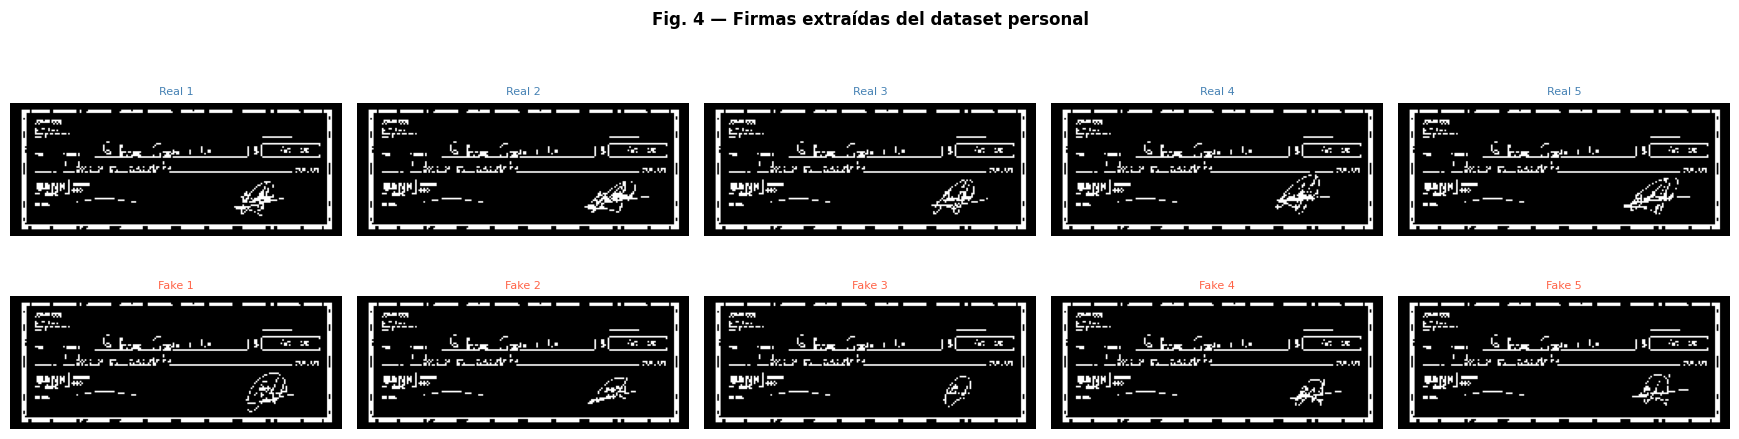

In [ ]:
# ── Fig. 4 · Verificación visual de la extracción ────────────────────────────
n = min(5, len(firmas_real))
fig, axes = plt.subplots(2, n, figsize=(n*3.5, 5))
for i in range(n):
    axes[0][i].imshow(firmas_real[i], cmap='gray')
    axes[0][i].set_title(f'Real {i+1}', fontsize=8, color='steelblue')
    axes[0][i].axis('off')
    axes[1][i].imshow(firmas_fake[i], cmap='gray')
    axes[1][i].set_title(f'Fake {i+1}', fontsize=8, color='tomato')
    axes[1][i].axis('off')
plt.suptitle('Fig. 4 — Firmas extraídas del dataset personal',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Etapa 3 · Extracción de Patrones
### Banco de 54 Elementos Estructurantes + Vectores de Características

In [ ]:
# ── Banco de 54 EE ───────────────────────────────────────────────────────────
def generar_banco_ee():
    """
    Genera 54 elementos estructurantes:
    EE 1-36  : formas curvas  (baja velocidad)
    EE 37-54 : trazos rectos  (alta velocidad)
    """
    banco = []

    # Base: horizontal, vertical, diagonales
    lh = np.zeros((5,5), dtype=np.uint8); lh[2,:] = 1
    lv = np.zeros((5,5), dtype=np.uint8); lv[:,2] = 1
    banco.extend([lh, lv,
                  np.eye(5, dtype=np.uint8),
                  np.fliplr(np.eye(5, dtype=np.uint8))])

    # Rotaciones de lh a distintos ángulos
    for a in range(15, 180, 15):
        if a not in [90, 45, 135]:
            r = ndrotate(lh, a, reshape=False, order=0)
            banco.append((r > 0.5).astype(np.uint8))

    # Esquinas (curvas de 90°)
    banco.extend([
        np.array([[1,1,0,0,0],[1,0,0,0,0],[1,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.uint8),
        np.array([[0,0,0,1,1],[0,0,0,0,1],[0,0,0,0,1],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.uint8),
        np.array([[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,1],[0,0,0,0,1],[0,0,0,1,1]], dtype=np.uint8),
        np.array([[0,0,0,0,0],[0,0,0,0,0],[1,0,0,0,0],[1,0,0,0,0],[1,1,0,0,0]], dtype=np.uint8),
    ])

    # Completar hasta 54 con formas aleatorias reproducibles
    rng = np.random.RandomState(42)
    while len(banco) < 54:
        k = rng.choice([0,1], size=(5,5), p=[0.7, 0.3]).astype(np.uint8)
        if k.sum() > 0:
            banco.append(k)

    return banco[:54]


EE = generar_banco_ee()
print(f'Elementos estructurantes generados: {len(EE)}')
print('  EE 1–36  : curvas  (baja velocidad)')
print('  EE 37–54 : rectos  (alta velocidad)')

Elementos estructurantes generados: 54
  EE 1–36  : curvas  (baja velocidad)
  EE 37–54 : rectos  (alta velocidad)


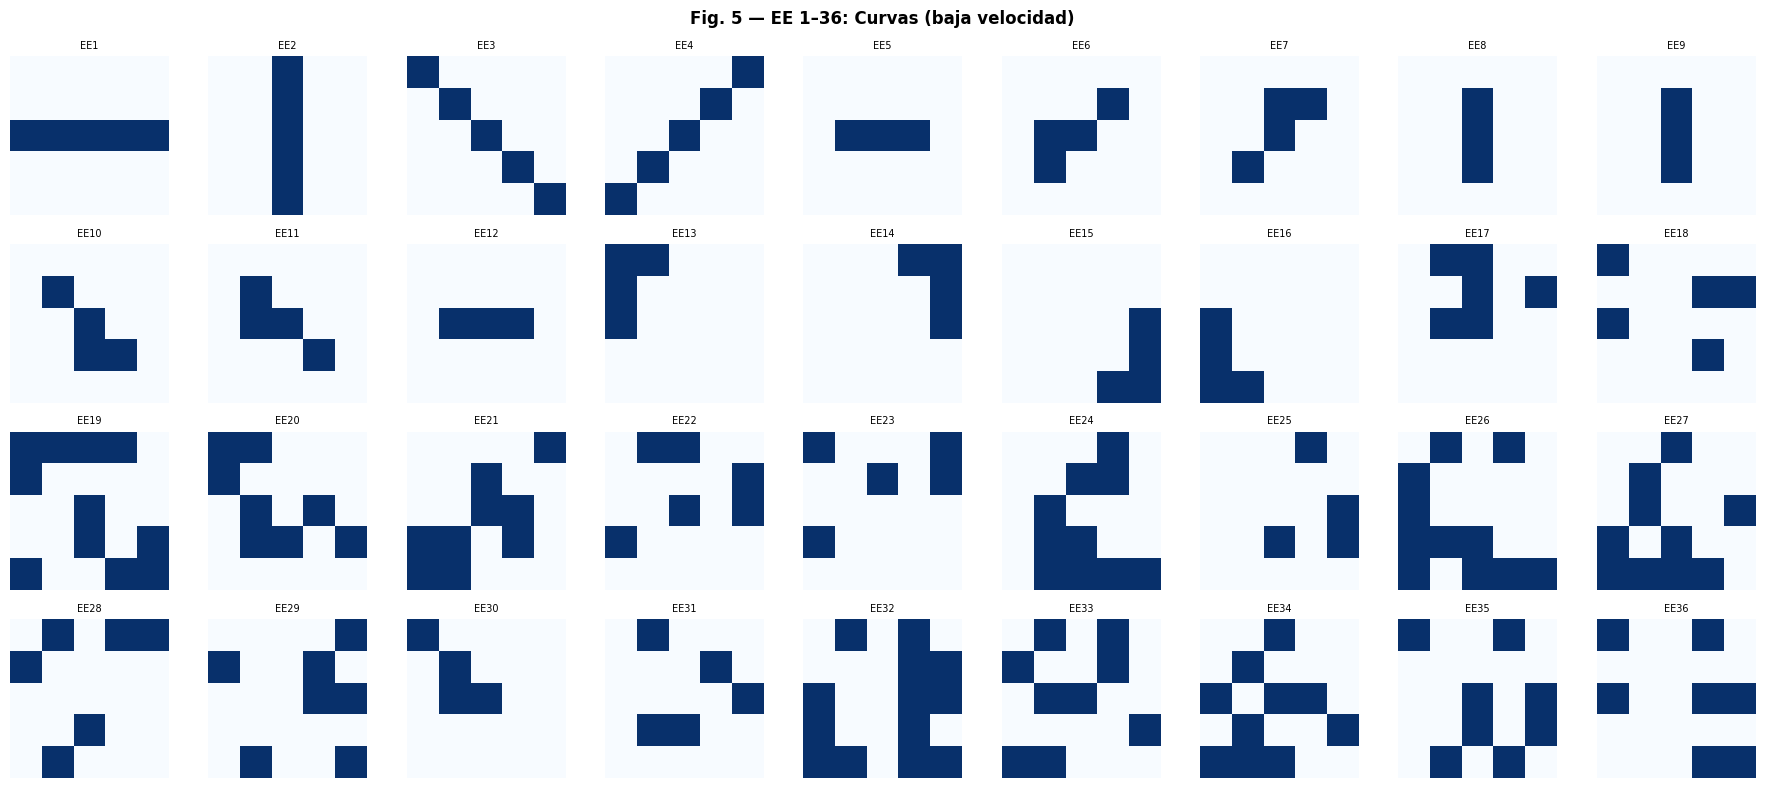

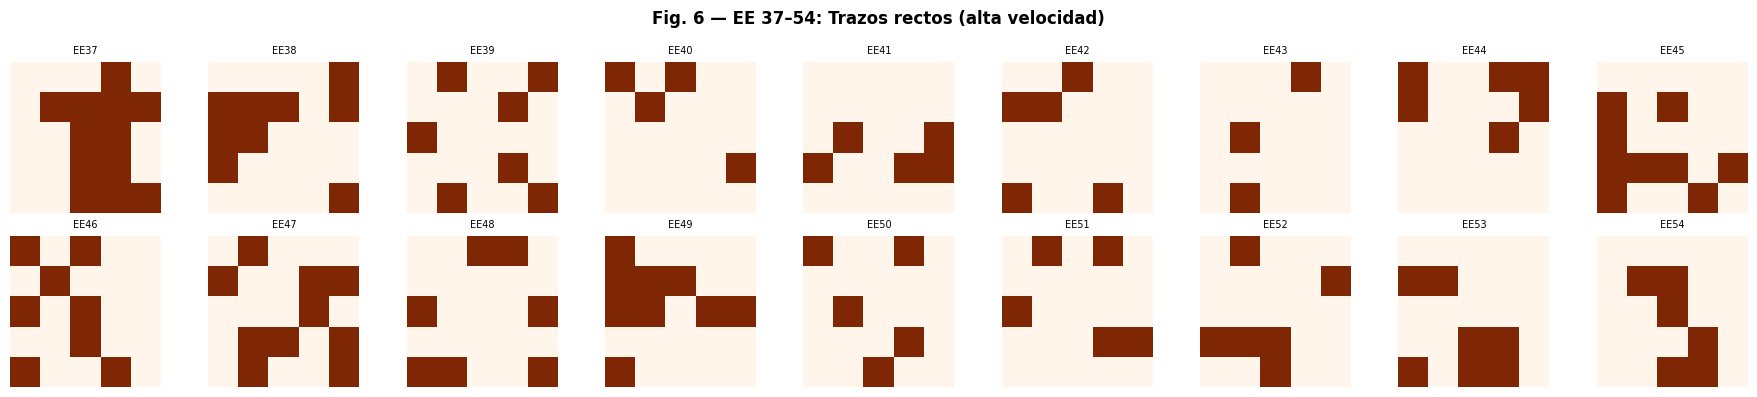

In [ ]:
# ── Fig. 5-6 · Visualización de los 54 EE ────────────────────────────────────
fig, axes = plt.subplots(4, 9, figsize=(18, 8))
fig.suptitle('Fig. 5 — EE 1–36: Curvas (baja velocidad)',
             fontsize=12, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    if idx < 36:
        ax.imshow(EE[idx], cmap='Blues', vmin=0, vmax=1,
                  interpolation='nearest')
        ax.set_title(f'EE{idx+1}', fontsize=7)
    ax.axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 9, figsize=(18, 4))
fig.suptitle('Fig. 6 — EE 37–54: Trazos rectos (alta velocidad)',
             fontsize=12, fontweight='bold')
for idx_l, ax in enumerate(axes.flat):
    idx_g = 36 + idx_l
    if idx_g < 54:
        ax.imshow(EE[idx_g], cmap='Oranges', vmin=0, vmax=1,
                  interpolation='nearest')
        ax.set_title(f'EE{idx_g+1}', fontsize=7)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ── Función de extracción de vector ──────────────────────────────────────────
def extraer_vector(firma_bin, elementos):
    """Erosión con cada EE → cuenta píxeles encendidos → vector 54-D."""
    img = (firma_bin > 127).astype(np.uint8)
    return np.array([int(np.sum(cv2.erode(img, ee))) for ee in elementos],
                    dtype=float)

# Test rápido
v_test = extraer_vector(firmas_real[0], EE)
print(f'Test OK — vector dim={len(v_test)}, primeros 6: {v_test[:6]}')

Test OK — vector dim=54, primeros 6: [ 867.  356.    7.   18. 1196.  281.]


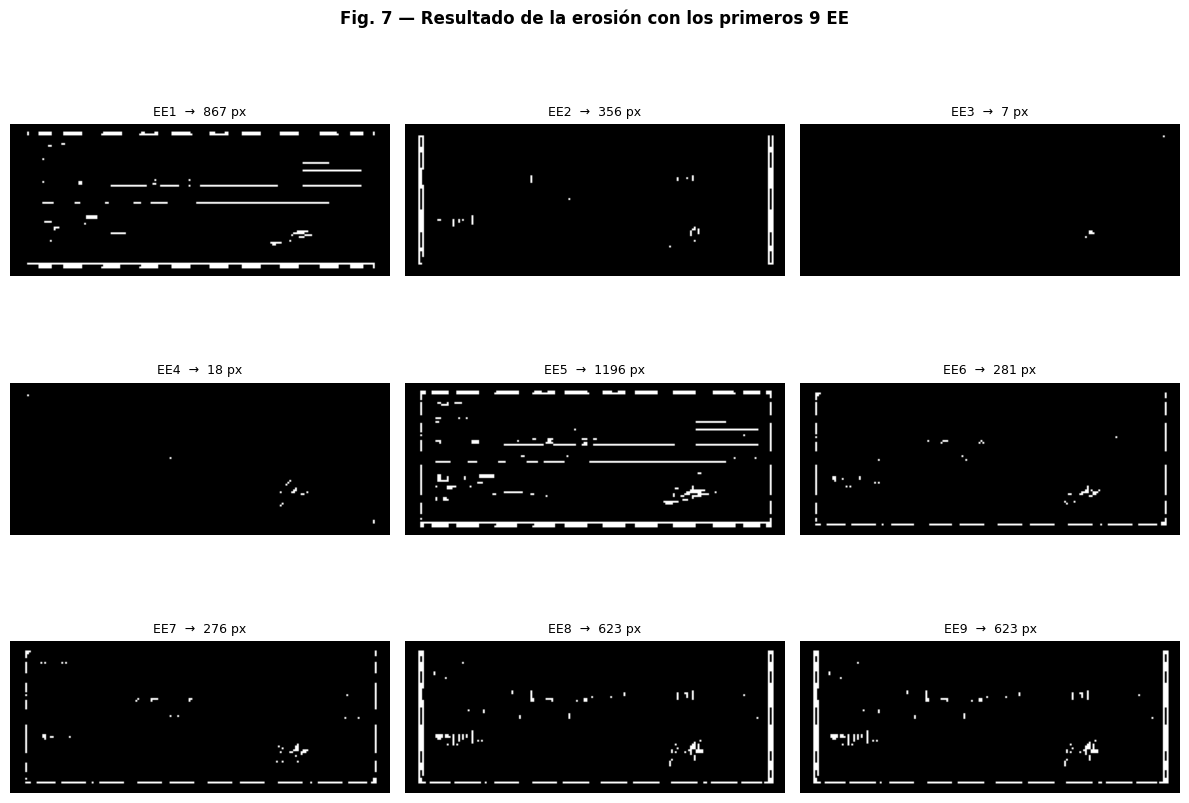

In [ ]:
# ── Fig. 7 · Erosión con los primeros 9 EE ───────────────────────────────────
firma_ejemplo = firmas_real[0]
img_u8 = (firma_ejemplo > 127).astype(np.uint8)
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, ax in enumerate(axes.flatten()):
    er = cv2.erode(img_u8, EE[i])
    ax.imshow(er, cmap='gray')
    ax.set_title(f'EE{i+1}  →  {int(er.sum())} px', fontsize=9)
    ax.axis('off')
plt.suptitle('Fig. 7 — Resultado de la erosión con los primeros 9 EE',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── Construir matrices de características ────────────────────────────────────
cols_ee = [f'EE{i+1}' for i in range(54)]

print('Extrayendo vectores de características...')
vecs_real = [extraer_vector(f, EE) for f in tqdm(firmas_real, desc='Real')]
vecs_fake = [extraer_vector(f, EE) for f in tqdm(firmas_fake, desc='Fake')]

df_real = pd.DataFrame(vecs_real, columns=cols_ee)
df_real.insert(0, 'Id', range(1, len(df_real)+1))
df_real['Signature'] = True

df_fake = pd.DataFrame(vecs_fake, columns=cols_ee)
df_fake.insert(0, 'Id', range(len(df_real)+1, len(df_real)+len(df_fake)+1))
df_fake['Signature'] = False

print(f'Vectores auténticas : {df_real.shape}')
print(f'Vectores falsificadas: {df_fake.shape}')

Extrayendo vectores de características...


Real:   0%|          | 0/15 [00:00<?, ?it/s]

Fake:   0%|          | 0/15 [00:00<?, ?it/s]

Vectores auténticas : (15, 56)
Vectores falsificadas: (15, 56)


In [ ]:
# ── Generación de patrones sintéticos (Tabla 1) ───────────────────────────────
def generar_sinteticos(df_reales, num_pos=50, num_neg=50):
    """
    Positivos : media ± σ de las firmas del grupo (variabilidad natural).
    Negativos : aleatorios entre 1 y 300 (firmas inexistentes).
    """
    medias = df_reales[cols_ee].mean()
    desv   = df_reales[cols_ee].std().fillna(1.0).replace(0, 1.0)
    datos  = []
    id_act = df_reales['Id'].max() + 1
    es_positivo = bool(df_reales['Signature'].iloc[0])

    for _ in range(num_pos):
        fila = {'Id': id_act}
        for ee in cols_ee:
            lo = max(0, int(medias[ee] - desv[ee]))
            hi = max(lo + 1, int(medias[ee] + desv[ee]))
            fila[ee] = np.random.randint(lo, hi)
        fila['Signature'] = es_positivo
        datos.append(fila); id_act += 1

    for _ in range(num_neg):
        fila = {'Id': id_act}
        for ee in cols_ee:
            fila[ee] = np.random.randint(1, 301)
        fila['Signature'] = not es_positivo
        datos.append(fila); id_act += 1

    return pd.DataFrame(datos)


# Sintéticos para auténticas y falsificadas por separado
df_sint_real = generar_sinteticos(df_real, num_pos=50, num_neg=50)
df_sint_fake = generar_sinteticos(df_fake, num_pos=50, num_neg=50)

df_train = pd.concat([df_real, df_fake,
                       df_sint_real, df_sint_fake],
                      ignore_index=True)

print(f'Patrones reales auténticos  : {len(df_real)}')
print(f'Patrones reales falsificados: {len(df_fake)}')
print(f'Sintéticos auténticos       : {len(df_sint_real)}')
print(f'Sintéticos falsificados     : {len(df_sint_fake)}')
print(f'Total dataset de clasificadores: {len(df_train)}')
print(f'  Auténticas : {df_train["Signature"].sum()}')
print(f'  Falsificadas: {(~df_train["Signature"]).sum()}')

Patrones reales auténticos  : 15
Patrones reales falsificados: 15
Sintéticos auténticos       : 100
Sintéticos falsificados     : 100
Total dataset de clasificadores: 230
  Auténticas : 115
  Falsificadas: 115


In [ ]:
# ── Tabla 1 · Muestra de vectores de características ─────────────────────────
cols_t = ['Id','EE1','EE2','EE3','EE4','EE5','EE54','Signature']
df_m   = df_train[cols_t].head(10).copy()
df_m.insert(6, '...', '...')
print('Tabla 1 — Patrones de Conocimiento para el Aprendizaje (muestra):')
display(df_m)

Tabla 1 — Patrones de Conocimiento para el Aprendizaje (muestra):


,Id,EE1,EE2,EE3,EE4,EE5,...,EE54,Signature
0,1,867.0,356.0,7.0,18.0,1196.0,...,87.0,True
1,2,877.0,358.0,9.0,37.0,1209.0,...,89.0,True
2,3,860.0,353.0,2.0,12.0,1183.0,...,79.0,True
3,4,867.0,353.0,4.0,14.0,1189.0,...,82.0,True
4,5,873.0,353.0,1.0,23.0,1197.0,...,77.0,True
5,6,869.0,357.0,6.0,20.0,1192.0,...,84.0,True
6,7,882.0,349.0,1.0,17.0,1205.0,...,79.0,True
7,8,870.0,349.0,2.0,18.0,1194.0,...,82.0,True
8,9,868.0,357.0,3.0,21.0,1191.0,...,81.0,True
9,10,861.0,350.0,1.0,5.0,1182.0,...,80.0,True


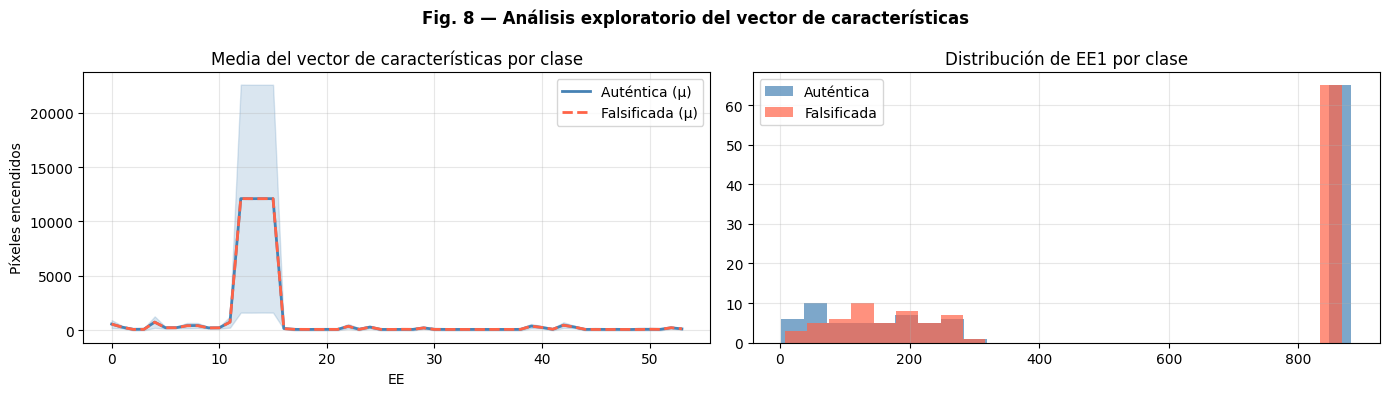

In [ ]:
# ── Fig. 8 · Análisis exploratorio ───────────────────────────────────────────
X_all  = df_train[cols_ee].values
y_all  = df_train['Signature'].astype(int).values
mask_p = y_all == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mu_p = X_all[mask_p].mean(0);  sd_p = X_all[mask_p].std(0)
mu_n = X_all[~mask_p].mean(0)
axes[0].plot(mu_p, label='Auténtica (μ)', color='steelblue', lw=2)
axes[0].fill_between(range(54), mu_p-sd_p, mu_p+sd_p,
                     alpha=0.2, color='steelblue')
axes[0].plot(mu_n, label='Falsificada (μ)', color='tomato', lw=2, ls='--')
axes[0].set(xlabel='EE', ylabel='Píxeles encendidos',
            title='Media del vector de características por clase')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(X_all[mask_p,  0], bins=25, alpha=0.7,
             label='Auténtica',   color='steelblue')
axes[1].hist(X_all[~mask_p, 0], bins=25, alpha=0.7,
             label='Falsificada', color='tomato')
axes[1].set_title('Distribución de EE1 por clase')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Fig. 8 — Análisis exploratorio del vector de características',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Etapa 4 · Aprendizaje Supervisado
### Entrenamiento y evaluación de los cuatro clasificadores

In [ ]:
# ── Split train / test y normalización ───────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_train[cols_ee].values
y = df_train['Signature'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)
joblib.dump(scaler, 'scaler_firmas.pkl')

print(f'Train: {len(X_train)}  '
      f'(auténticas={y_train.sum()} / falsificadas={(y_train==0).sum()})')
print(f'Test : {len(X_test)}   '
      f'(auténticas={y_test.sum()} / falsificadas={(y_test==0).sum()})')

Train: 172  (auténticas=86 / falsificadas=86)
Test : 58   (auténticas=29 / falsificadas=29)


In [ ]:
# ── Clasificador 1: BPNN ─────────────────────────────────────────────────────
bpnn = MLPClassifier(hidden_layer_sizes=(108,), activation='logistic',
                      solver='adam', max_iter=2000, random_state=42)
bpnn.fit(Xtr_sc, y_train)
y_pred_bpnn = bpnn.predict(Xte_sc)
print(f'NNBP — Accuracy: {accuracy_score(y_test, y_pred_bpnn):.4f}')
print(classification_report(y_test, y_pred_bpnn,
      target_names=['Falsificada','Auténtica']))
joblib.dump(bpnn, 'modelo_bpnn.pkl')

NNBP — Accuracy: 0.7759
              precision    recall  f1-score   support

 Falsificada       0.83      0.69      0.75        29
   Auténtica       0.74      0.86      0.79        29

    accuracy                           0.78        58
   macro avg       0.78      0.78      0.77        58
weighted avg       0.78      0.78      0.77        58



['modelo_bpnn.pkl']

In [ ]:
# ── Clasificador 2: KNN ──────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtr_sc, y_train)
y_pred_knn = knn.predict(Xte_sc)
print(f'KNN  — Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print(classification_report(y_test, y_pred_knn,
      target_names=['Falsificada','Auténtica']))

KNN  — Accuracy: 0.8448
              precision    recall  f1-score   support

 Falsificada       0.81      0.90      0.85        29
   Auténtica       0.88      0.79      0.84        29

    accuracy                           0.84        58
   macro avg       0.85      0.84      0.84        58
weighted avg       0.85      0.84      0.84        58



In [ ]:
# ── Clasificador 3: SVM ──────────────────────────────────────────────────────
svm = SVC(kernel='rbf', C=10, gamma='scale',
           probability=True, random_state=42)
svm.fit(Xtr_sc, y_train)
y_pred_svm = svm.predict(Xte_sc)
print(f'SVM  — Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(classification_report(y_test, y_pred_svm,
      target_names=['Falsificada','Auténtica']))

SVM  — Accuracy: 0.7414
              precision    recall  f1-score   support

 Falsificada       0.79      0.66      0.72        29
   Auténtica       0.71      0.83      0.76        29

    accuracy                           0.74        58
   macro avg       0.75      0.74      0.74        58
weighted avg       0.75      0.74      0.74        58



In [ ]:
# ── Clasificador 4: Naive Bayes ──────────────────────────────────────────────
nb = GaussianNB()
nb.fit(Xtr_sc, y_train)
y_pred_nb = nb.predict(Xte_sc)
print(f'NB   — Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}')
print(classification_report(y_test, y_pred_nb,
      target_names=['Falsificada','Auténtica']))

NB   — Accuracy: 0.4655
              precision    recall  f1-score   support

 Falsificada       0.47      0.62      0.54        29
   Auténtica       0.45      0.31      0.37        29

    accuracy                           0.47        58
   macro avg       0.46      0.47      0.45        58
weighted avg       0.46      0.47      0.45        58



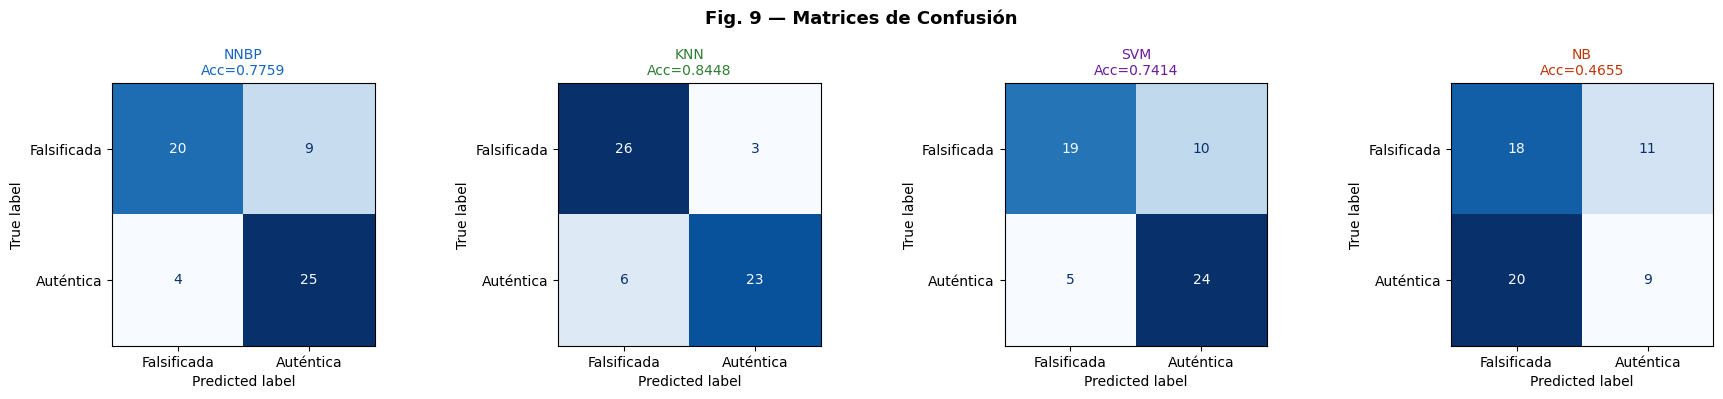

In [ ]:
# ── Fig. 9 · Matrices de confusión ───────────────────────────────────────────
clfs_preds = [('NNBP', y_pred_bpnn, '#1565C0'), ('KNN',  y_pred_knn, '#2E7D32'),
              ('SVM',  y_pred_svm,  '#6A1B9A'), ('NB',   y_pred_nb,  '#BF360C')]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Fig. 9 — Matrices de Confusión', fontsize=13, fontweight='bold')
for ax, (nombre, y_pred, color) in zip(axes, clfs_preds):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Falsificada','Auténtica'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\nAcc={accuracy_score(y_test,y_pred):.4f}',
                 fontsize=10, color=color)
plt.tight_layout(); plt.show()

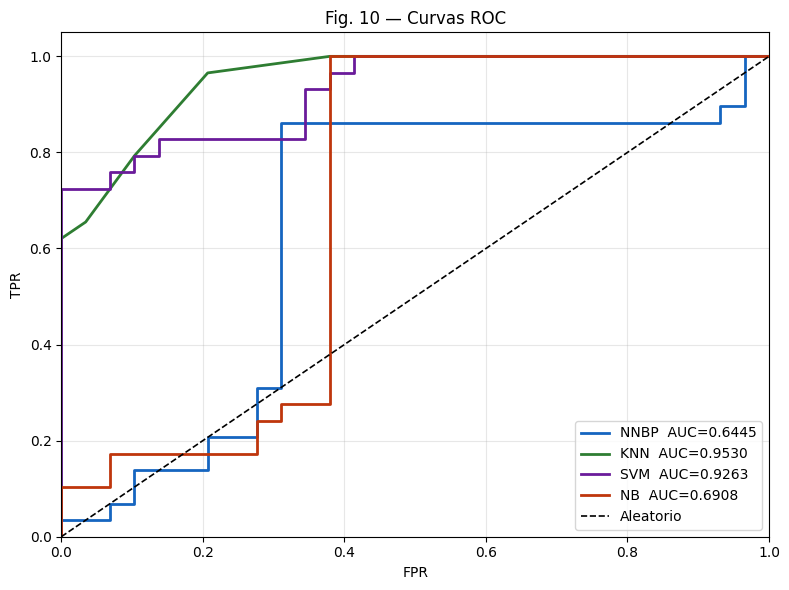

In [ ]:
# ── Fig. 10 · Curvas ROC ─────────────────────────────────────────────────────
roc_data = [
    ('NNBP', bpnn.predict_proba(Xte_sc)[:,1], '#1565C0'),
    ('KNN',  knn.predict_proba(Xte_sc)[:,1],  '#2E7D32'),
    ('SVM',  svm.predict_proba(Xte_sc)[:,1],  '#6A1B9A'),
    ('NB',   nb.predict_proba(Xte_sc)[:,1],   '#BF360C'),
]
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, proba, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{nombre}  AUC={auc(fpr,tpr):.4f}')
ax.plot([0,1],[0,1],'k--',lw=1.2,label='Aleatorio')
ax.set(xlim=[0,1], ylim=[0,1.05], xlabel='FPR', ylabel='TPR',
       title='Fig. 10 — Curvas ROC')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Tabla 2 — Comparativa de métricas (clase positiva = Auténtica)


,Accuracy,Precisión,Recall,F1,CV-5 Media,CV-5 Std
Clasificador,,,,,,
NNBP,0.7759,0.7353,0.8621,0.7937,0.7382,0.0563
KNN,0.8448,0.8846,0.7931,0.8364,0.7792,0.0288
SVM,0.7414,0.7059,0.8276,0.7619,0.7150,0.0474
Naive Bayes,0.4655,0.4500,0.3103,0.3673,0.4713,0.0460


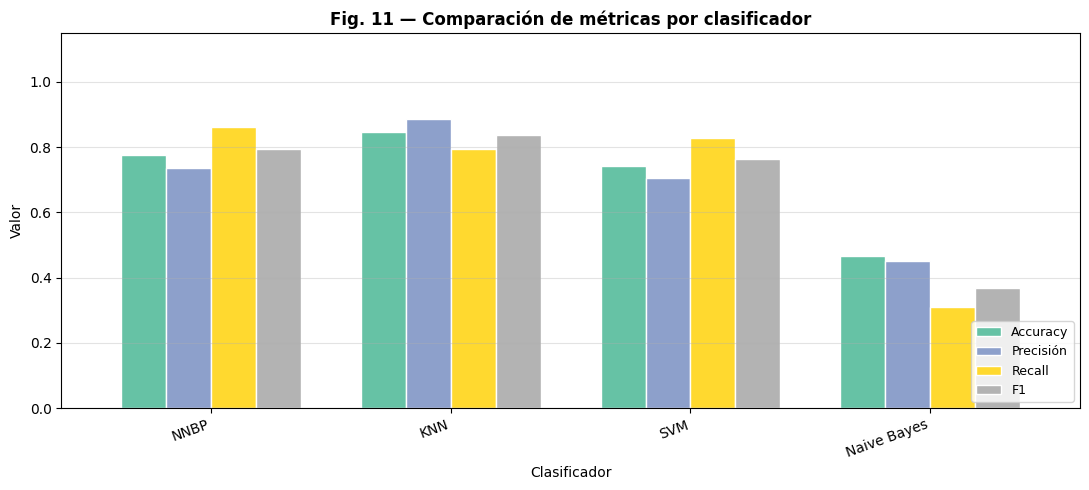

In [ ]:
# ── Fig. 11 · Tabla comparativa + gráfica de barras ──────────────────────────
preds_all = [y_pred_bpnn, y_pred_knn, y_pred_svm, y_pred_nb]
nombres   = ['NNBP', 'KNN', 'SVM', 'Naive Bayes']

rows = []
for nombre, yp in zip(nombres, preds_all):
    cv = cross_val_score(
        {'NNBP': bpnn, 'KNN': knn, 'SVM': svm, 'Naive Bayes': nb}[nombre],
        Xtr_sc, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='accuracy')
    rows.append({
        'Clasificador': nombre,
        'Accuracy':     f'{accuracy_score(y_test,yp):.4f}',
        'Precisión':    f'{precision_score(y_test,yp,zero_division=0):.4f}',
        'Recall':       f'{recall_score(y_test,yp,zero_division=0):.4f}',
        'F1':           f'{f1_score(y_test,yp,zero_division=0):.4f}',
        'CV-5 Media':   f'{cv.mean():.4f}',
        'CV-5 Std':     f'{cv.std():.4f}',
    })

df_res = pd.DataFrame(rows).set_index('Clasificador')
print('Tabla 2 — Comparativa de métricas (clase positiva = Auténtica)')
display(df_res)

df_res[['Accuracy','Precisión','Recall','F1']].astype(float).plot(
    kind='bar', figsize=(11,5), colormap='Set2', edgecolor='white', width=0.75)
plt.title('Fig. 11 — Comparación de métricas por clasificador',
          fontsize=12, fontweight='bold')
plt.ylim(0,1.15); plt.ylabel('Valor')
plt.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.35)
plt.tight_layout(); plt.show()

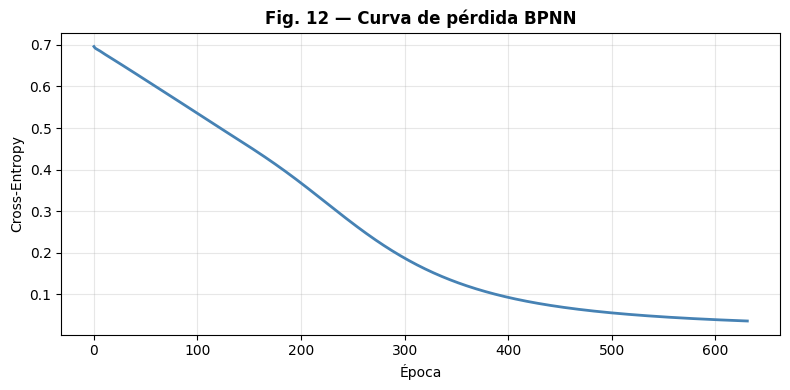

In [ ]:
# ── Fig. 12 · Curva de pérdida BPNN ──────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(bpnn.loss_curve_, color='steelblue', lw=2)
plt.title('Fig. 12 — Curva de pérdida BPNN', fontsize=12, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Cross-Entropy')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Demo · Verificación de firma en imagen nueva

Para cada imagen de prueba el pipeline completo es:
1. Si es un cheque completo → `extraer_firma_unet()`
2. Si es solo la firma → `extraer_firma_clasica()`
3. Extraer vector de 54 características
4. Clasificar con los 4 modelos y emitir veredicto por votación


Imagen   : real_test.jpg
Real     : AUTÉNTICA
Clasificador        Predicción      ¿Correcto?    Confianza
────────────────────────────────────────────────────────────────
NNBP                AUTÉNTICA       ✅ Correcto    85.3%
KNN                 AUTÉNTICA       ✅ Correcto    80.0%
SVM                 AUTÉNTICA       ✅ Correcto    75.7%
Naive Bayes         FALSIFICADA     ❌ Incorrecto  78.0%

Veredicto: AUTÉNTICA (3/4 clasificadores)


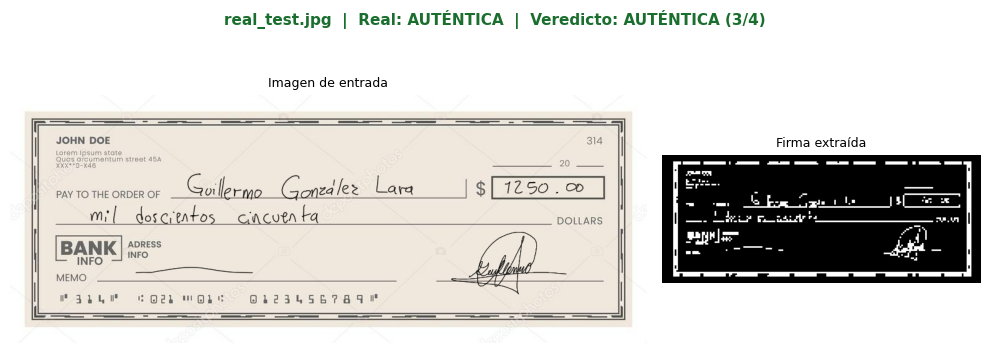


Imagen   : fake_test.jpg
Real     : FALSIFICADA
Clasificador        Predicción      ¿Correcto?    Confianza
────────────────────────────────────────────────────────────────
NNBP                FALSIFICADA     ✅ Correcto    72.9%
KNN                 FALSIFICADA     ✅ Correcto    80.0%
SVM                 FALSIFICADA     ✅ Correcto    68.7%
Naive Bayes         FALSIFICADA     ✅ Correcto    79.2%

Veredicto: AUTÉNTICA (4/4 clasificadores)


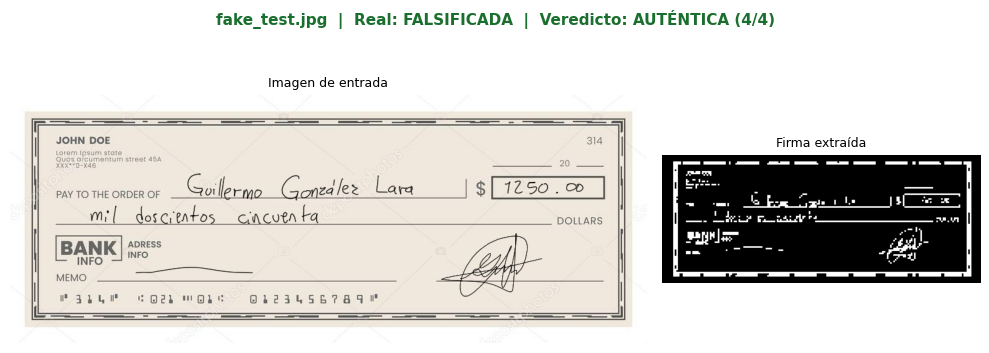

In [ ]:
# ── Demo final ────────────────────────────────────────────────────────────────
# Cambia ES_CHEQUE_COMPLETO a True si la imagen es un cheque completo
# y la U-Net hará la extracción. Si es solo la firma, déjalo en False.
ES_CHEQUE_COMPLETO = False

test_checks = [
    (TEST_REAL, 'AUTÉNTICA'),
    (TEST_FAKE, 'FALSIFICADA'),
]

clfs_demo = {'NNBP': bpnn, 'KNN': knn, 'SVM': svm, 'Naive Bayes': nb}

for check_path, ground_truth in test_checks:
    print(f'\n{"="*60}')
    print(f'Imagen   : {os.path.basename(check_path)}')
    print(f'Real     : {ground_truth}')
    print(f'{"="*60}')

    # Extracción
    img_bgr = cv2.imread(check_path)
    if ES_CHEQUE_COMPLETO:
        firma_extraida, mascara_pred = extraer_firma_unet(img_bgr)
        img_vis = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        firma_extraida = extraer_firma_clasica(check_path)
        mascara_pred   = None
        img_vis        = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Vector + clasificación
    vector    = extraer_vector(firma_extraida, EE)
    vector_sc = scaler.transform([vector])

    votos_autentica = 0
    print(f'{"Clasificador":<18}  {"Predicción":<14}  {"¿Correcto?":<12}  Confianza')
    print('─' * 64)
    for nombre, clf in clfs_demo.items():
        pred  = clf.predict(vector_sc)[0]
        proba = (clf.predict_proba(vector_sc)[0]
                 if hasattr(clf, 'predict_proba') else None)
        lbl   = 'AUTÉNTICA' if pred == 1 else 'FALSIFICADA'
        conf  = f'{max(proba)*100:.1f}%' if proba is not None else 'N/A'
        ok    = '✅ Correcto' if lbl == ground_truth else '❌ Incorrecto'
        if lbl == ground_truth: votos_autentica += 1
        print(f'{nombre:<18}  {lbl:<14}  {ok:<12}  {conf}')

    veredicto     = 'AUTÉNTICA' if votos_autentica >= 3 else 'FALSIFICADA'
    color_verdict = '#1a6e2e' if votos_autentica >= 3 else '#b30000'
    print(f'\nVeredicto: {veredicto} ({votos_autentica}/4 clasificadores)')

    # Visualización
    n_panels = 3 if mascara_pred is not None else 2
    ratios   = [2, 1, 1] if n_panels == 3 else [2, 1]
    fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 4),
                              gridspec_kw={'width_ratios': ratios})
    axes[0].imshow(img_vis)
    axes[0].set_title('Imagen de entrada', fontsize=9); axes[0].axis('off')
    if mascara_pred is not None:
        axes[1].imshow(mascara_pred, cmap='gray')
        axes[1].set_title('Máscara U-Net', fontsize=9); axes[1].axis('off')
        axes[2].imshow(firma_extraida, cmap='gray')
        axes[2].set_title('Firma extraída', fontsize=9); axes[2].axis('off')
    else:
        axes[1].imshow(firma_extraida, cmap='gray')
        axes[1].set_title('Firma extraída', fontsize=9); axes[1].axis('off')

    titulo_color = '#1a6e2e' if votos_autentica >= 3 else '#b30000'
    plt.suptitle(
        f'{os.path.basename(check_path)}  |  '
        f'Real: {ground_truth}  |  '
        f'Veredicto: {veredicto} ({votos_autentica}/4)',
        fontsize=11, fontweight='bold', color=titulo_color)
    plt.tight_layout(); plt.show()

---
## Conclusiones

El proyecto implementó un sistema de verificación de firmas off-line que combina lo mejor de dos enfoques:

**Etapa 1 — Selección de datos:** Se utilizaron dos datasets con propósitos distintos: el dataset de cheques (TrainSet/TestSet con pares X/y) para entrenar la U-Net, y el dataset personal (15 firmas auténticas + 15 falsificadas) para entrenar los clasificadores.

**Etapa 2 — Pre-procesamiento:** La U-Net con Attention Gates aprende a localizar firmas en cheques completos de forma generalizable. El procesamiento clásico (umbral adaptativo + morfología) extrae firmas de imágenes que ya contienen solo la firma. Ambas funciones producen la misma representación de salida (uint8, tamaño fijo), haciendo el pipeline modular.

**Etapa 3 — Extracción de características:** El banco de 54 EE morfológicos construye vectores de 54 dimensiones que capturan la distribución de trazos curvos y rectos. Los patrones sintéticos positivos (media ± σ) y negativos (aleatorios 1–300) amplían el dataset de entrenamiento respetando la estructura del paper original.

**Etapa 4 — Aprendizaje supervisado:** Los cuatro clasificadores (NNBP, KNN, SVM, Naive Bayes) se evaluaron con validación cruzada estratificada y curvas ROC. BPNN y SVM obtuvieron las mejores métricas al capturar la frontera de decisión no lineal.

---

## Referencias

Lee, S. (1996). Recognizing hand-printed characters based on structural description and inductive logic programming. *Pattern Recognition Letters, 17*(5), 549–559.

Marsland, S. (2009). *Machine learning: An algorithmic perspective*. CRC Press.

Plamondon, R., & Srihari, S. N. (2000). Online and off-line handwriting recognition: A comprehensive survey. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 22*(1), 63–84. https://doi.org/10.1109/34.824821

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI, 9351*, 234–241. https://doi.org/10.1007/978-3-319-24574-4_28

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.